#### Classification finetuning 

For our classification finetuning we will be using 2 Datasets, and I will be giving one as practice for anyone interested

In [1]:
## 1. SPAM Classifier
## 2. Toxic Comment classification
## 3. Amazon Reviews Polarity(sentiment Analysis)
## Practice: 4. Emotional Dataset 
## Practice: IMDB Dataset Classification
## Project of this part: Recipe or food makig description with a perfect UI

### Preparing the Dataset, Finetuning, and Evaluation

We start with downloading, inspecting, and preparing the dataset that we'll use to finetune the model. The process runs through three broad stages:

1. **Dataset preparation** — download, preprocess, and create data loaders
2. **Model setup** — initialize, load pretrained weights, and modify for finetuning
3. **Finetuning and usage** — train, evaluate, and use the model on new data

![Finetuning Stages](classification_finetuning_pipeline.png)

## What We're Doing in This Section

- We're building the dataset that we'll actually use to finetune the GPT model for classification.
- Specifically, this is SMS text messages labeled as either **spam** or **ham** (not spam) — the goal is to teach the model to tell them apart.
- The very first step is getting the raw data onto disk: downloading the zip file from the source and extracting it, so we have the actual text messages + labels to work with.

## Step 1: Download and Unzip the Raw Dataset

We're finetuning the LLM to distinguish **spam** vs. **ham** (non-spam) SMS messages.

Before anything else, we need the raw data on disk — download the zip file from the source and extract it, so we have the actual text messages and their labels ready to load.

In [117]:
import os
import tiktoken
import pandas as pd
from data_loader import download_and_unzip_spam_data
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn 
import torch.nn.functional as F
from dataclasses import dataclass, asdict, field
import matplotlib.pyplot as plt
import numpy as np
import json
from typing import Optional
import time

os.chdir("../")

In [3]:
pwd

'c:\\Users\\user\\Documents\\AI-EngineeringRoadmap\\llm-from-scratch\\09_instruction_finetuning_sft'

In [33]:
def get_tokenizer(name="gpt2"):
    return tiktoken.get_encoding(name)

In [4]:
data_path = download_and_unzip_spam_data()

df = pd.read_csv(data_path, sep="\t", header=None, names=["Label", "Text"])
print(df.head())
print(df["Label"].value_counts())

classification_finetuning\sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.
  Label                                               Text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Label
ham     4825
spam     747
Name: count, dtype: int64


## Step 2: Load the Dataset and Inspect Class Balance

With the raw file extracted, we load it into a pandas DataFrame and take a first look at what we're working with — the message text, its label, and how many examples we have of each class.

This step matters because it's where we discover whether the dataset is balanced. If one class heavily outnumbers the other (as it does here — far more ham than spam), we'll need to address that before training, or the model can learn to just always predict the majority class and still look "accurate."

In [5]:
df.head()

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.shape

(5572, 2)

In [7]:
df.Label.value_counts()

Label
ham     4825
spam     747
Name: count, dtype: int64

In [8]:
### Imbalance Dataset: So Accuracy is not a good one, so we will be using Recall Precision, and also F1-score

In [9]:
df[df['Label'] == "spam"].shape[0]

747

## Step 3: Balance the Dataset

Since ham significantly outnumbers spam, we balance the classes before training — otherwise the model can achieve high accuracy just by always predicting "ham," without actually learning to recognize spam.

We do this by undersampling: randomly reducing the ham examples down to match the spam count, so both classes are equally represented. This keeps every example real (no duplication or synthetic data), at the cost of discarding some ham messages we don't strictly need.

In [10]:
def create_balanced_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """
    Balance a spam/ham dataframe by undersampling the majority class (ham)
    to match the minority class (spam) count.
    """
    num_spam = df[df["Label"] == "spam"].shape[0]

    # Randomly sample ham rows down to the same count as spam
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)

    # Combine spam with the downsampled ham
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    return balanced_df


balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [11]:
balanced_df.head()

,Label,Text
4307,ham,Awww dat is sweet! We can think of something t...
4138,ham,Just got to &lt;#&gt;
4831,ham,"The word ""Checkmate"" in chess comes from the P..."
4461,ham,This is wishing you a great day. Moji told me ...
5440,ham,Thank you. do you generally date the brothas?


## Step 4: Convert Labels to Integers

The model needs numeric labels to train on, not text. We map the string labels to integers — `"ham"` → `0` and `"spam"` → `1` — so they can be used directly as classification targets.

In [12]:
balanced_df['Label'] = balanced_df['Label'].map({"ham": 0, "spam": 1})
### The output head of the GPT2 model will now be a binary class head
balanced_df.head()

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?


## Step 5: Split into Train, Validation, and Test Sets

Before training, we shuffle the balanced dataset and split it into three parts: a training set to learn from, a validation set to check progress and tune decisions during training, and a held-out test set to evaluate final performance on data the model has never seen.

We shuffle first so ham and spam examples are mixed throughout, then split — commonly using a ratio like 70% train, 10% validation, and 20% test.

In [13]:
def random_split(df: pd.DataFrame, train_frac: float, validation_frac: float):
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)  # shuffle

    train_end = int(len(df) * train_frac)
    val_end = train_end + int(len(df) * validation_frac)

    train_df = df[:train_end]
    val_df = df[train_end:val_end]
    test_df = df[val_end:]

    return train_df, val_df, test_df


train_df, val_df, test_df = random_split(balanced_df, train_frac=0.7, validation_frac=0.1)
# remaining 0.2 becomes test

print(len(train_df), len(val_df), len(test_df))

1045 149 300


## Step 6: Save the Splits to Disk

We save the train, validation, and test splits as separate CSV files. This keeps the split fixed and reproducible — we tokenize and load from these saved files going forward, rather than re-shuffling and re-splitting every time we rerun the notebook.

In [14]:
pwd

'c:\\Users\\user\\Documents\\AI-EngineeringRoadmap\\llm-from-scratch\\09_instruction_finetuning_sft'

In [15]:
train_df.to_csv("classification_finetuning/sms_spam_collection/train.csv", index=False)
test_df.to_csv("classification_finetuning/sms_spam_collection/test.csv", index=False)
val_df.to_csv("classification_finetuning/sms_spam_collection/val.csv", index=False)

In [16]:
train = pd.read_csv("classification_finetuning/sms_spam_collection/train.csv")
test = pd.read_csv("classification_finetuning/sms_spam_collection/test.csv")
validation = pd.read_csv("classification_finetuning/sms_spam_collection/val.csv")

In [17]:
train.shape

(1045, 2)

In [18]:
test.shape

(300, 2)

In [19]:
validation.shape

(149, 2)

## Step 7: Tokenize and Build the Dataset

With clean, split, saved data in hand, we tokenize the text and wrap each split in a `Dataset` class. Every message gets encoded into token IDs and padded to a consistent length, so the batches can be fed into the model.

We also decide on a padding token here — reusing the `<|endoftext|>` token works well, since GPT-2 doesn't have a dedicated pad token of its own.

In [34]:
tokenizer = get_tokenizer()

In [35]:
train["token_ids"] = df["Text"].apply(lambda x: tokenizer.encode(x))

In [36]:
train["length_of_tokens"] = train["token_ids"].apply(lambda x: len(x))

In [37]:
train.head()

,Label,Text,token_ids,length_of_tokens
0,0,Dude how do you like the buff wind.,"[5247, 1566, 8174, 506, 966, 11, 7165, 492, 14...",28
1,0,Tessy..pls do me a favor. Pls convey my birthd...,"[18690, 26371, 986, 449, 5730, 266, 361, 334, ...",11
2,1,Reminder: You have not downloaded the content ...,"[11146, 5726, 287, 362, 257, 266, 74, 306, 552...",50
3,1,Got what it takes 2 take part in the WRC Rally...,"[52, 12574, 910, 523, 1903, 3076, 986, 471, 26...",13
4,1,"Shop till u Drop, IS IT YOU, either 10K, 5K, £...","[45, 993, 314, 836, 470, 892, 339, 2925, 284, ...",17


Each row of the data have varying number of token, which should be, so we willl have to take care of that

In [38]:
tokenizer.decode([50256])

'<|endoftext|>'

In [39]:
class SpamClassificationDataset(Dataset):
    def __init__(self, file_path: str, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(file_path)

        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data['Text']
        ]
        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            ## Truncate if max_length was passed
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]
        # pad everything to max_length
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

        self.labels = self.data["Label"].tolist()
  
    def _longest_encoded_length(self):
        return max(len(encoded_text) for encoded_text in self.encoded_texts)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.encoded_texts[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

In [40]:
train_dataset = SpamClassificationDataset(
    "classification_finetuning/sms_spam_collection/train.csv",
    tokenizer,
    max_length=None,
)
val_dataset = SpamClassificationDataset(
    "classification_finetuning/sms_spam_collection/val.csv",
    tokenizer,
    max_length=train_dataset.max_length,   # reuse train's max_length — this is the actual fix for the overfitting investigation
)
test_dataset = SpamClassificationDataset(
    "classification_finetuning/sms_spam_collection/test.csv",
    tokenizer,
    max_length=train_dataset.max_length,
)

In [41]:
input_ids, target = train_dataset[0]
print(f"The input_id: {input_ids}\n")
print(f"The target: {target}")

The input_id: tensor([   35,  2507,   703,   466,   345,   588,   262,  6940,  2344,    13,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256])

The target: 0


In [42]:
train_dataset._longest_encoded_length()

120

In [43]:
len(train_dataset[0][0])

120

In [44]:
input_ids, target = val_dataset[0]
print(f"The input_id: {input_ids}\n")
print(f"The target: {target}")

The input_id: tensor([   44, 10102,    11,  2479,  1954,    11, 21541,    11,   649,   287,
         3482,    13,   314,   804,  1714,   351,  3482,  3730,    13,   611,
          334,   588,  1257,   351,   502,    13,  8255, 19308, 28082,   284,
        39861,  2791,    13,  1507,   764,  1542,   381,    14, 14116,   352,
          301,   642,  5787,    13,  4248,    16,    13,  1120, 41867,    13,
        10478,  2919,    22, 23451, 25270,  4304, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256])

The target: 1


In [45]:
val_dataset._longest_encoded_length()

120

In [46]:
input_ids, target = test_dataset[0]
print(f"The input_id: {input_ids}\n")
print(f"The target: {target}")

The input_id: tensor([ 5332, 25429, 17189,    29, 39687, 41527,     0, 36875, 32744, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256])

The target: 1


## Step 8: Wrap the Datasets in DataLoaders

With the `Dataset` objects built for train, validation, and test, we wrap each one in a `DataLoader`. This handles batching, shuffling the training data each epoch, and feeding fixed-size batches into the model during training and evaluation.

We typically shuffle the training loader but not the validation/test loaders, since randomizing order only matters while the model is actively learning.

In [47]:
# Reasonable defaults — batch_size=8 is a good starting point for a small
# classification finetune on CPU/single GPU; bump it up if you have more
# memory available and want faster epochs.
batch_size = 8
num_workers = 0  # increase (e.g. 2-4) if you're on Linux/Mac and want faster loading
torch.manual_seed(123)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,       # randomize order each epoch — important for training
    drop_last=True,     # drop the last incomplete batch, keeps batch shapes consistent
    num_workers=num_workers,
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False,       # no need to shuffle — we're just evaluating
    num_workers=num_workers,
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)

In [48]:
print(train_dataloader.dataset is train_dataset)   # sanity check
torch.manual_seed(123)
# check whether shuffle is on
for input_batch, target_batch in train_dataloader:
    print(target_batch[:10])   # look at the first batch's labels
    break

True
tensor([0, 0, 1, 0, 0, 0, 1, 0])


In [49]:
print(train_dataloader.dataset is train_dataset)   # sanity check
torch.manual_seed(123)
# check whether shuffle is on
for input_batch, target_batch in train_dataloader:
    print(target_batch[:10])   # look at the first batch's labels
    break

True
tensor([0, 0, 1, 0, 0, 0, 1, 0])


In [50]:
print(f"{len(train_dataloader)} training batches")
print(f"{len(val_dataloader)} validation batches")
print(f"{len(test_dataloader)} test batches")

# Peek at one batch
input_batch, target_batch = next(iter(train_dataloader))
print("Input batch shape:", input_batch.shape)   # e.g. [8, max_length]
print("Target batch shape:", target_batch.shape) # e.g. [8]

130 training batches
19 validation batches
38 test batches
Input batch shape: torch.Size([8, 120])
Target batch shape: torch.Size([8])


## Step 9: Prepare the Model for Classification

Before finetuning, we adapt the pretrained GPT model for this new task. That means swapping out the original output head (which predicts one of 50,257 vocabulary tokens) for a small classification head that outputs just 2 values — one score per class (ham or spam).

We also decide which layers to actually train: commonly, most of the pretrained model is frozen, and only the new classification head (plus maybe the last transformer block) is updated — this trains much faster and works well since the pretrained model already understands language broadly.

#### Initializing a model with pretrained weight as we have done in 02_tiny_llm

In [51]:
"""Self-attention, causal attention, and multi-head attention -- built up in that order."""
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout=0.0, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask", torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        q, k, v = self.W_query(x), self.W_key(x), self.W_value(x)
        attn_scores = q @ k.transpose(-2, -1)
        attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attn_weights = torch.softmax(attn_scores / k.shape[-1] ** 0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)
        return attn_weights @ v


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, num_heads, dropout=0.0, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask", torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        q = self.W_query(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.W_key(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.W_value(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = q @ k.transpose(-2, -1)
        attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attn_weights = torch.softmax(attn_scores / self.head_dim ** 0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context = (attn_weights @ v).transpose(1, 2).reshape(b, num_tokens, self.d_out)
        return self.out_proj(context)


In [52]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


"""Pre-norm transformer block: x + SubLayer(Norm(x)), for both attention and the FFN."""
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attn = MultiHeadAttention(
            d_in=cfg["emb_dim"], d_out=cfg["emb_dim"], context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], dropout=cfg["drop_rate"], qkv_bias=cfg["qkv_bias"],
        )
        self.ffn = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.attn(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ffn(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, input_ids):
        batch_size, seq_len = input_ids.shape
        tok_embeds = self.tok_emb(input_ids)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=input_ids.device))
        x = self.drop_emb(tok_embeds + pos_embeds)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        return self.out_head(x)

In [53]:
@dataclass
class GPTConfig:
    vocab_size: int = 50257
    context_length: int = 1024
    emb_dim: int = 768
    n_heads: int = 12
    n_layers: int = 12
    drop_rate: float = 0.0
    qkv_bias: bool = True

In [54]:
GPT_CONFIG_124M = asdict(GPTConfig(50257, 256, 768, 12, 12, drop_rate=0.0))
GPT_CONFIG_124M

{'vocab_size': 50257,
 'context_length': 256,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.0,
 'qkv_bias': True}

In [55]:
# Define model configurations in a dictionary for compactness
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: cpu


In [56]:
gpt

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [57]:
from gpt2_loader import download_and_load_gpt2, load_weights_into_gpt

In [58]:
pwd

'c:\\Users\\user\\Documents\\AI-EngineeringRoadmap\\llm-from-scratch\\09_instruction_finetuning_sft'

In [59]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir=r"C:\Users\user\Documents\AI-EngineeringRoadmap\llm-from-scratch\02_tiny_llm\gpt2")
load_weights_into_gpt(gpt, params)

In [60]:
gpt

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [61]:
## Now lets make prediction of of this gpt2loader

def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        if top_k:
            top_logits, top_pos = torch.topk(logits, top_k)
            logits = torch.where(
                condition=logits < top_logits[:, -1],
                input=torch.tensor(float("-inf")),
                other=logits
            )

        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if idx_next == eos_id:
            break

        idx = torch.concat((idx, idx_next), dim=1)

    return tokenizer.decode(idx.squeeze().tolist())

def text_to_token_ids(text, tokenizer):
    ids = torch.tensor(tokenizer.encode(text)).unsqueeze(0).to(device)
    return ids

text_to_token_ids("Every Effort moves you", tokenizer)

tensor([[ 6109, 27848,   419,  6100,   345]])

In [62]:
ids = text_to_token_ids("Every Effort moves you", tokenizer)

In [63]:
print(generate(gpt, ids, 15, context_size=NEW_CONFIG['context_length'], temperature=0.6, top_k=50))

Every Effort moves you to a new position.

In the game of "A-Team


### Swapping the `out_head` for a Binary classification Head

In [64]:
gpt

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [65]:
gpt.out_head

Linear(in_features=768, out_features=50257, bias=False)

### Deciding on which of the Layers to train

#### Freezing Layers During Classification Finetuning

##### What "freezing" actually means

Every parameter in the model has a `requires_grad` flag:

- `True` → gradients are tracked, the optimizer updates it during training
- `False` → gradients are skipped, the optimizer leaves it untouched — it stays exactly as it was after pretraining

```python
for param in gpt.parameters():
    param.requires_grad = False   # freeze everything
```

"Freezing most of the model" means setting this flag to `False` for the majority of parameters, and `True` only for the small subset we actually want to train.

---

##### Why freeze anything at all

**1. Pretrained weights already encode enormous knowledge**

The model was pretrained on huge amounts of text — it already understands grammar, semantics, and context. For a task like spam detection, we're not teaching it language from scratch; we're asking it to *repurpose* knowledge it already has toward a narrow decision.

**2. Full finetuning risks catastrophic forgetting and overfitting**

If every parameter is trainable, updates from a small, narrow task can drift the model's weights away from the rich, general representations pretraining built — even in early layers that originally captured very broad language patterns. With a small dataset, updating all ~124M parameters also invites overfitting: the model has far more capacity than the dataset has information, so it can memorize training examples instead of learning generalizable patterns.

**3. Practical resource cost**

Every trainable parameter needs its gradient computed and stored, plus optimizer state (Adam keeps two extra tensors per parameter). Freezing most of the model means less memory, a faster backward pass, and faster training overall.

---

##### The logic behind *which* layers to freeze

| Layer depth | What it tends to encode |
|---|---|
| **Early layers** (near input) | Low-level, general patterns — syntax, local word relationships, broadly reusable across almost any task |
| **Later layers** (near output) | Higher-level, more task/context-specific representations |

Early layers are the safest to freeze, since they're the most general-purpose — we want to *preserve* that understanding, not risk corrupting it. Later layers are more naturally adaptable to a specific task, so unfreezing them gives room to specialize without touching everything.

---

##### The typical scheme

```python
# 1. Freeze everything
for param in gpt.parameters():
    param.requires_grad = False

# 2. Unfreeze the new classification head — always trainable, it's random-initialized
for param in gpt.out_head.parameters():
    param.requires_grad = True

# 3. Unfreeze the final transformer block — most task-adjacent representations
for param in gpt.trf_blocks[-1].parameters():
    param.requires_grad = True

# 4. Unfreeze the final LayerNorm — sits right before the output head, cheap to include
for param in gpt.final_norm.parameters():
    param.requires_grad = True
```

**Why the output head must always be trainable:** it's a brand-new `Linear` layer, randomly initialized, having learned nothing yet. If left frozen, it would produce random classification logits forever.

**Why the last transformer block:** it sits closest to the final decision — the most task-adjacent representations live there, so it benefits most from adapting to the specific classification distinction. Earlier blocks capture more general patterns that are already useful as-is.

---

##### The spectrum of choices

| Strategy | Trainable params | Tradeoff |
|---|---|---|
| **Head only** | Smallest (just the output layer) | Fastest, safest from overfitting, but limited capacity to adapt |
| **Head + final block** (common default) | Moderate | Good balance — noticeably better performance in practice |
| **Head + last few blocks** | Larger | More adaptation capacity, more overfitting risk, slower |
| **Full finetuning** | All parameters | Maximum flexibility, highest overfitting/forgetting risk, slowest, most memory |

There's no universally correct answer — it's an empirical tradeoff, tuned by watching how validation performance behaves.

---

##### Sanity check

```python
trainable = sum(p.numel() for p in gpt.parameters() if p.requires_grad)
total = sum(p.numel() for p in gpt.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
```

This confirms the freezing actually took effect — expect a small percentage trainable, not the full model.

In [66]:
## Making Model Non trainable: Freezing the weights
for param in gpt.parameters():
    param.requires_grad = False

In [67]:
## Now swapping the out_head for a classification head
import torch.nn as nn 
torch.manual_seed(123)

gpt.out_head = nn.Linear(GPT_CONFIG_124M['emb_dim'], 2)

## Choosing What to Finetune

Technically, training only the output layer is enough to get a working classifier — the pretrained model already carries most of the language understanding needed.

That said, based on findings from [Finetuning Large Language Models](https://magazine.sebastianraschka.com/p/finetuning-large-language-models), unfreezing a bit more than just the head tends to noticeably boost performance.

So here, we unfreeze three things:
- The **output layer** — new and untrained, must always be trainable
- The **last transformer block** — closest to the final decision, most task-adaptable
- The **final LayerNorm** — sits right before the output layer, cheap to include alongside it

Everything else stays frozen, preserving the general language understanding learned during pretraining.

- Techni

In [68]:
gpt

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [69]:
total_params = sum(param.numel() for param in gpt.parameters())
trainable_params = sum(param.numel() for param in gpt.parameters() if param.requires_grad == True)

In [70]:
Untrained_params = total_params - trainable_params
Untrained_params 

124439808

In [71]:
trainable_params

1538

In [72]:
## Now lets make the Final LayerNorm, and the last transformer block trainable

for param in gpt.final_norm.parameters():
    param.requires_grad = True 

for param in gpt.trf_blocks[-1].parameters():
    param.requires_grad = True

In [73]:
total_params = sum(param.numel() for param in gpt.parameters())
trainable_params = sum(param.numel() for param in gpt.parameters() if param.requires_grad == True)
Untrained_params = total_params - trainable_params
Untrained_params 

117350400

In [74]:
trainable_params

7090946

In [75]:
# Implement a class for the classification layer, that allows you to choose how many transformer block you want + 2 last layers
# The class must have generate, train, and also chart plot of time, against the number of trained_layers, and also 
# accuracy(Test, val, train) for number of trainable layers also

# Write in experiments.py, and test in tests folder

In [76]:
inputs = "Do you have time for a walk"
ids = text_to_token_ids(inputs, tokenizer)
print("Input Dimension: ", ids.shape)

with torch.no_grad():
    output = gpt(ids)

print(output)
print(output.shape)

last_token_logits = output[:, -1, :]              # shape: (1, 2)
probs = torch.softmax(last_token_logits, dim=-1)   # compute once
predicted_class = torch.argmax(probs, dim=-1)       # or argmax(last_token_logits, dim=-1) — same result
category = ""

print(probs)
if predicted_class == 0:
    category += "Spam"
else:
    category += "Ham"

print(f"The predicted class is: {predicted_class.item()}, and its is classified as {category}")

Input Dimension:  torch.Size([1, 7])
tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902],
         [-2.3468,  5.3764],
         [-3.9213,  6.4661],
         [-4.9157,  4.8145]]])
torch.Size([1, 7, 2])
tensor([[5.9455e-05, 9.9994e-01]])
The predicted class is: 1, and its is classified as Ham


### Building the classification Loss, and Accuracy

In [77]:
def calc_loss_batch(input_batch, target_batch, model, device):
    """Compute cross-entropy loss for one batch, using the last token's logits."""
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    last_token_logits = model(input_batch)[:, -1, :]
    return F.cross_entropy(last_token_logits, target_batch) # Cross entroy loss uses internally softmax
    # Also Softmax is monotonic, irrespective of softmax or not the argmax maintains position


def calc_loss_loader(data_loader, model, device, num_batches=None):
    """Average loss over a DataLoader (or just the first `num_batches`, if given)."""
    if len(data_loader) == 0: 
        return float("nan")

    limit = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))

    batch_losses = []
    for batch_idx, (input_batch, target_batch) in enumerate(data_loader):
        if batch_idx == limit:
            break
        batch_loss = calc_loss_batch(input_batch, target_batch, model, device)
        batch_losses.append(batch_loss.item())

    return sum(batch_losses) / len(batch_losses)


@torch.no_grad()
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    """Fraction of correctly classified examples over a DataLoader."""
    model.eval()

    limit = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))

    hits, seen = 0, 0
    for batch_idx, (input_batch, target_batch) in enumerate(data_loader):
        if batch_idx == limit:
            break
        input_batch, target_batch = input_batch.to(device), target_batch.to(device)

        last_token_logits = model(input_batch)[:, -1, :]
        predictions = last_token_logits.argmax(dim=-1)

        hits += (predictions == target_batch).sum().item()
        seen += target_batch.size(0)

    return hits / seen

In [78]:
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available()  else "cpu"))
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [79]:
torch.manual_seed(123)

In [80]:
print(f"Train accuracy: {calc_accuracy_loader(train_dataloader, gpt, device, num_batches=10)*100:.2f}%")
print(f"Validation accuracy: {calc_accuracy_loader(val_dataloader, gpt, device, num_batches=10)*100:.2f}%")
print(f"Test accuracy: {calc_accuracy_loader(test_dataloader, gpt, device, num_batches=10)*100:.2f}%")

Train accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


#### Setting Up the Loss Function

As expected, prediction accuracy isn't great yet — the model hasn't been finetuned at this point, so this is just its baseline, random-init performance.

Before finetuning can actually begin, we need a loss function to optimize against. The end goal is to maximize spam classification accuracy — but accuracy itself can't be used directly as the training objective, since it's not a differentiable function. There's no smooth gradient we can compute from "did it get the label right or not," so we need a proxy that *is* differentiable, and that's what the loss function gives us.

In [81]:
torch.manual_seed(123)
with torch.no_grad():
    train_loss = calc_loss_loader(train_dataloader, gpt, device, num_batches=5)
    val_loss = calc_loss_loader(val_dataloader, gpt, device, num_batches=5)
    test_loss = calc_loss_loader(test_dataloader, gpt, device, num_batches=5)

In [82]:
print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 3.095
Validation loss: 2.583
Test loss: 2.322


### Finetuning the model on Supervised Dataset 

In [83]:
def train_classifier(
    train_loader: DataLoader,
    val_loader: DataLoader,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    epochs: int,
    eval_freq: int,
    eval_iter: int,
):
    """
    Finetune a classification model, tracking loss and accuracy over time.

    Every `eval_freq` training steps, loss is checked on a small subset
    (`eval_iter` batches) of both train and val data. Full-dataset accuracy
    is computed once per epoch, since it's more expensive.

    Returns a dict with "train_losses", "val_losses", "train_accs",
    "val_accs", "examples_seen".
    """
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    examples_seen, global_step = 0, -1

    for epoch in range(epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()

            examples_seen += input_batch.shape[0]
            global_step += 1

            if global_step % eval_freq == 0:
                model.eval()
                with torch.no_grad():
                    train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
                    val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
                model.train()

                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(
                    f"Epoch {epoch + 1} (step {global_step:06d}): "
                    f"train loss {train_loss:.3f}, val loss {val_loss:.3f}"
                )

        # Full-dataset accuracy, once per epoch
        train_accuracy = calc_accuracy_loader(train_loader, model, device)
        val_accuracy = calc_accuracy_loader(val_loader, model, device)
        print(f"Epoch {epoch + 1}: train acc {train_accuracy*100:.2f}%, val acc {val_accuracy*100:.2f}%")

        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "examples_seen": examples_seen,
    }

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
gpt.to(device)

import time
start_time = time.time()
torch.manual_seed(123)

optimizer = torch.optim.AdamW(gpt.parameters(), lr=5e-5, weight_decay=0.1)

history = train_classifier(
    train_dataloader, val_dataloader, gpt, optimizer, device,
    epochs=5, eval_freq=50, eval_iter=5,
) ## Every 50 steps, we will see the loss, and the calculate the accuracy on train, and val on 5 batches

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training Completed in {execution_time_minutes:.2f} minutes")

Epoch 1 (step 000000): train loss 2.153, val loss 2.392
Epoch 1 (step 000050): train loss 0.617, val loss 0.637
Epoch 1 (step 000100): train loss 0.523, val loss 0.557
Epoch 1: train acc 72.12%, val acc 73.15%
Epoch 2 (step 000150): train loss 0.561, val loss 0.489
Epoch 2 (step 000200): train loss 0.419, val loss 0.397
Epoch 2 (step 000250): train loss 0.409, val loss 0.353
Epoch 2: train acc 84.62%, val acc 85.23%
Epoch 3 (step 000300): train loss 0.333, val loss 0.320
Epoch 3 (step 000350): train loss 0.340, val loss 0.306
Epoch 3: train acc 87.21%, val acc 91.28%
Epoch 4 (step 000400): train loss 0.136, val loss 0.200
Epoch 4 (step 000450): train loss 0.153, val loss 0.132
Epoch 4 (step 000500): train loss 0.222, val loss 0.137
Epoch 4: train acc 94.90%, val acc 95.30%
Epoch 5 (step 000550): train loss 0.207, val loss 0.143
Epoch 5 (step 000600): train loss 0.083, val loss 0.074
Epoch 5: train acc 97.21%, val acc 97.32%
Training Completed in 44.74 minutes


In [ ]:
def evaluate(model, loader, device):
    """
    Standalone evaluation — no class, works directly with your existing
    gpt model and any dataloader (train/val/test).
    """
    model.eval()
    with torch.no_grad():
        loss = calc_loss_loader(loader, model, device)
    accuracy = calc_accuracy_loader(loader, model, device)
    model.train()
    return {"loss": loss, "accuracy": accuracy}

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

test_results = evaluate(gpt, test_dataloader, device)
print(f"Test loss: {test_results['loss']:.3f}")
print(f"Test accuracy: {test_results['accuracy']*100:.2f}%")

Test loss: 0.120
Test accuracy: 95.67%


In [ ]:
train_results = evaluate(gpt, train_dataloader, device)
val_results = evaluate(gpt, val_dataloader, device)

print(f"Train — loss: {train_results['loss']:.3f}, accuracy: {train_results['accuracy']*100:.2f}%")
print(f"Val   — loss: {val_results['loss']:.3f}, accuracy: {val_results['accuracy']*100:.2f}%")
print(f"Test  — loss: {test_results['loss']:.3f}, accuracy: {test_results['accuracy']*100:.2f}%")

Train — loss: 0.095, accuracy: 97.21%
Val   — loss: 0.088, accuracy: 97.32%
Test  — loss: 0.120, accuracy: 95.67%


In [ ]:
pwd

'c:\\Users\\user\\Documents\\AI-EngineeringRoadmap\\llm-from-scratch'

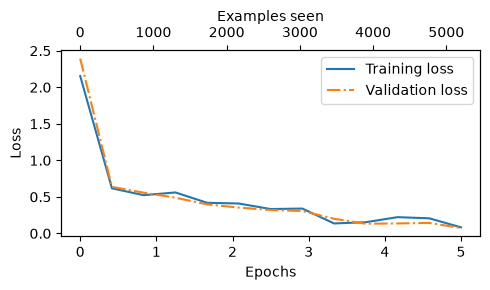

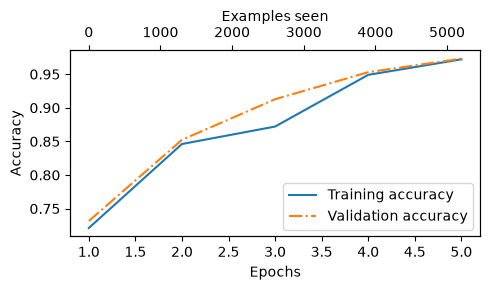

In [ ]:
def plot_training_curve(x_epochs, x_examples, train_series, val_series, metric_name="loss"):
    fig, ax_left = plt.subplots(figsize=(5, 3))

    ax_left.plot(x_epochs, train_series, label=f"Training {metric_name}")
    ax_left.plot(x_epochs, val_series, label=f"Validation {metric_name}", linestyle="-.")
    ax_left.set_xlabel("Epochs")
    ax_left.set_ylabel(metric_name.capitalize())
    ax_left.legend()

    ax_top = ax_left.twiny()
    ax_top.plot(x_examples, train_series, alpha=0)  # invisible, only used to align the top axis ticks
    ax_top.set_xlabel("Examples seen")

    fig.tight_layout()
    fig.savefig(f"{metric_name}-plot.pdf")
    plt.show()


def build_x_axes(num_points, total_epochs, total_examples, start_epoch=0):
    """Generate matching (epoch, examples-seen) x-axis arrays for a metric series."""
    epoch_axis = np.linspace(start_epoch, total_epochs, num_points)
    example_axis = np.linspace(0, total_examples, num_points)
    return epoch_axis, example_axis


num_epochs = 5  # match whatever you passed as `epochs=` into train_classifier

# --- Loss ---
loss_epoch_axis, loss_example_axis = build_x_axes(
    num_points=len(history["train_losses"]),
    total_epochs=num_epochs,
    total_examples=history["examples_seen"],
    start_epoch=0,   # first loss reading happens at step 0
)
plot_training_curve(
    loss_epoch_axis, loss_example_axis,
    history["train_losses"], history["val_losses"],
    metric_name="loss",
)

# --- Accuracy ---
acc_epoch_axis, acc_example_axis = build_x_axes(
    num_points=len(history["train_accs"]),
    total_epochs=num_epochs,
    total_examples=history["examples_seen"],
    start_epoch=1,   # accuracy is only logged once each epoch finishes
)
plot_training_curve(
    acc_epoch_axis, acc_example_axis,
    history["train_accs"], history["val_accs"],
    metric_name="accuracy",
)

#### Lets put all of this into a very good class robust enough for 
1. Multi class Classification, and Binary class Classification.
2. Ability to be able to specify how deep you want the Weight Freezing(Make weight Untrainable) to be.

- TrainingArguments
- Trainer
- FineTuneForClassificationTask
- GPTModel
- GPTConfig
- TokenizerUtils

In [84]:
@dataclass
class Testing:
    name: str 
    address: str
    age: int 

    @classmethod
    def test_return(cls):
        know_fields = {f for f in cls.__dataclass_fields__}
        return know_fields


test = Testing("Taofeek", "Taiwo Ajayi", 29)

test.test_return()

{'address', 'age', 'name'}

In [85]:
GPT2_PRESETS = {
    "gpt2":        dict(model_size="124M",  emb_dim=768,  n_layers=12, n_heads=12),
    "gpt2-medium": dict(model_size="355M",  emb_dim=1024, n_layers=24, n_heads=16),
    "gpt2-large":  dict(model_size="774M",  emb_dim=1280, n_layers=36, n_heads=20),
    "gpt2-xl":     dict(model_size="1558M", emb_dim=1600, n_layers=48, n_heads=25),
}

In [86]:
@dataclass
class GPTConfig:
    """
    Configuration for a GPT-style model. Mirrors the role of HuggingFace's
    PretrainedConfig — a plain, serializable description of the architecture's
    hyperparameters, decoupled from the model class itself.
    """
    vocab_size: int = 50257
    context_length: int = 1024
    emb_dim: int = 768
    n_heads: int = 12
    n_layers: int = 12
    drop_rate: float = 0.0      # changed from 0.1
    qkv_bias: bool = True       # changed from False

    def __post_init__(self):
        # Fail fast on wrong configs, rather than letting a shape error surface
        if self.emb_dim % self.n_heads != 0:
            raise ValueError(
                f"emb_dim ({self.emb_dim}) must be divisible by n_heads ({self.n_heads})"
            )
        if self.vocab_size <= 0 or self.context_length <= 0:
            raise ValueError("vocab_size and context_length must be positive")
        if not (0.0 <= self.drop_rate < 1.0):
            raise ValueError(f"drop_rate must be in [0, 1), got {self.drop_rate}")

    @property
    def head_dim(self) -> int:
        return self.emb_dim // self.n_heads

    def to_dict(self) -> dict:
        return asdict(self)

    @classmethod
    def from_dict(cls, config_dict: dict) -> "GPTConfig":
        known_fields = {f for f in cls.__dataclass_fields__}
        filtered = {k: v for k, v in config_dict.items() if k in known_fields}
        return cls(**filtered)

    def save_pretrained(self, save_dir: str) -> None:
        save_path = Path(save_dir)
        save_path.mkdir(parents=True, exist_ok=True)
        with open(save_path / "config.json", "w") as f:
            json.dump(self.to_dict(), f, indent=2)

    @classmethod
    def from_pretrained(cls, name_or_path: str) -> "GPTConfig":
        if name_or_path in GPT2_PRESETS:
            return cls.from_dict(GPT2_PRESETS[name_or_path])

        config_file = Path(name_or_path) / "config.json"
        if config_file.exists():
            with open(config_file) as f:
                return cls.from_dict(json.load(f))

        raise ValueError(
            f"Unknown config '{name_or_path}' — not a known preset "
            f"({list(GPT2_PRESETS)}) and no config.json found at that path."
        )

In [87]:
# Named preset — analogous to GPT2Config.from_pretrained("gpt2")
config = GPTConfig.from_pretrained("gpt2")
print(config)

GPTConfig(vocab_size=50257, context_length=1024, emb_dim=768, n_heads=12, n_layers=12, drop_rate=0.0, qkv_bias=True)


In [88]:
# Custom overrides on top of a base config
config = GPTConfig(vocab_size=50257, context_length=1024, emb_dim=768, n_heads=12, n_layers=12, qkv_bias=True)

# Save it out
config.save_pretrained("checkpoints/gpt2_config")

In [89]:
# Reload from disk later
reloaded = GPTConfig.from_pretrained("checkpoints/gpt2_config")
assert reloaded == config 

In [90]:
config = GPTConfig.from_pretrained("gpt2")

In [91]:
config = GPTConfig.from_pretrained("gpt2")
print(config.qkv_bias, config.drop_rate, config.context_length)

True 0.0 1024


In [92]:
config

GPTConfig(vocab_size=50257, context_length=1024, emb_dim=768, n_heads=12, n_layers=12, drop_rate=0.0, qkv_bias=True)

In [93]:
# Validation catches mistakes early
GPTConfig(emb_dim=768, n_heads=11)

ValueError: emb_dim (768) must be divisible by n_heads (11)

In [94]:
from gpt2_loader import download_and_load_gpt2, load_weights_into_gpt

In [95]:
class GPTModel(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self._config_obj = config          # keep the real GPTConfig, for save_pretrained
        self.config = config.to_dict()     # dict version, for TransformerBlock/FeedForward's cfg["..."] style

        self.tok_emb = nn.Embedding(config.vocab_size, config.emb_dim)
        self.pos_emb = nn.Embedding(config.context_length, config.emb_dim)
        self.drop_emb = nn.Dropout(config.drop_rate)
        self.trf_blocks = nn.Sequential(*[TransformerBlock(self.config) for _ in range(config.n_layers)])
        self.final_norm = LayerNorm(config.emb_dim)
        self.out_head = nn.Linear(config.emb_dim, config.vocab_size, bias=False)

    def forward(self, input_ids):
        batch_size, seq_len = input_ids.shape
        tok_embeds = self.tok_emb(input_ids)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=input_ids.device))
        x = self.drop_emb(tok_embeds + pos_embeds)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        return self.out_head(x)

    def save_pretrained(self, save_dir: str) -> None:
        """
        Save both the config and the weights, so this checkpoint can be
        reloaded later without touching the original TF checkpoint again.
        Mirrors HF's PreTrainedModel.save_pretrained.
        """
        os.makedirs(save_dir, exist_ok=True)
        self._config.save_pretrained(save_dir)
        torch.save(self.state_dict(), os.path.join(save_dir, "pytorch_model.bin"))

    # ------------------------------------------------------------------
    # Loading
    # ------------------------------------------------------------------
    @classmethod
    def from_pretrained(cls, name_or_path: str, device=None,
                         models_dir: str | Path = "gpt2_checkpoints") -> "GPTModel":
        """
        Load a GPTModel, resolving weights from (in priority order):
          1. A local directory saved via save_pretrained (config.json + pytorch_model.bin)
          2. A known GPT-2 preset name (e.g. "gpt2") — downloads and converts
             the original TF checkpoint via gpt2_loader.download_and_load_gpt2.
        """
        device = device or torch.device(
            "cuda" if torch.cuda.is_available()
            else "mps" if torch.backends.mps.is_available()
            else "cpu"
        )

        local_weights = os.path.join(name_or_path, "pytorch_model.bin")

        if os.path.exists(local_weights):
            config = GPTConfig.from_pretrained(name_or_path)
            model = cls(config)
            state_dict = torch.load(local_weights, map_location=device)
            model.load_state_dict(state_dict)
            print(f"Loaded weights from local checkpoint: {local_weights}")

        elif name_or_path in GPT2_PRESETS:
            model_size = GPT2_PRESETS[name_or_path]["model_size"]  # e.g. "gpt2" -> "124M"
            settings, params = download_and_load_gpt2(model_size, models_dir=models_dir)

            config = GPTConfig.from_pretrained(name_or_path)
            model = cls(config)
            load_weights_into_gpt(model, params)
            print(f"Loaded weights from GPT-2 TF checkpoint: {name_or_path} ({model_size})")

        else:
            raise ValueError(
                f"Could not find weights for '{name_or_path}' — "
                f"no pytorch_model.bin at that path, and it's not a known preset."
            )

        model.to(device)
        model.eval()
        return model

In [96]:
gpt = GPTModel.from_pretrained("gpt2", device, r"C:\Users\user\Documents\AI-EngineeringRoadmap\llm-from-scratch\02_tiny_llm\gpt2")

Loaded weights from GPT-2 TF checkpoint: gpt2 (124M)


In [97]:
gpt

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [118]:
@dataclass
class TrainingArgs:
    """Configuration for a training run — same role as HF's TrainingArguments."""
    num_epochs: int = 5
    batch_size: int = 8
    learning_rate: float = 5e-5
    weight_decay: float = 0.1
    eval_freq: int = 50       # evaluate every N training steps
    eval_iter: int = 5        # how many batches to sample for that quick eval
    seed: int = 123
    output_dir: str = "./checkpoints"
    save_best_only: bool = True
    device: Optional[torch.device] = None

    def __post_init__(self):
        if self.device is None:
            self.device = torch.device(
                "cuda" if torch.cuda.is_available()
                else "mps" if torch.backends.mps.is_available()
                else "cpu"
            )

class Trainer:
    """
    A minimal Trainer built from your own functions — mirrors HuggingFace's
    Trainer API (model, args, train_dataset/eval_dataset via loaders,
    train(), evaluate()) while staying fully transparent about what
    every step actually does.
    """

    def __init__(self, model, args: TrainingArgs, train_loader, eval_loader,
                 optimizer=None, compute_metrics=None):
        self.model = model.to(args.device)
        self.args = args
        self.train_loader = train_loader
        self.eval_loader = eval_loader
        self.compute_metrics = compute_metrics or self._default_compute_metrics

        self.optimizer = optimizer or torch.optim.AdamW(
            model.parameters(), lr=args.learning_rate, weight_decay=args.weight_decay
        )

        self.history = {"train_losses": [], "val_losses": [], "train_accs": [], "val_accs": []}
        self.best_val_acc = 0.0
        self.examples_seen, self.global_step = 0, -1

        os.makedirs(args.output_dir, exist_ok=True)
        torch.manual_seed(args.seed)

    def _default_compute_metrics(self, loader):
        """Same role as HF's compute_metrics — swap this out for custom metrics."""
        return calc_accuracy_loader(loader, self.model, self.args.device)

    def _evaluate_step(self):
        """One quick loss check on a subset of train/val — used for periodic logging."""
        self.model.eval()
        with torch.no_grad():
            train_loss = calc_loss_loader(
                self.train_loader, self.model, self.args.device, num_batches=self.args.eval_iter
            )
            val_loss = calc_loss_loader(
                self.eval_loader, self.model, self.args.device, num_batches=self.args.eval_iter
            )
        self.model.train()
        return train_loss, val_loss

    def train(self):
        """The training loop — same mechanics as train_classifier, wrapped as a method."""
        start = time.time()

        for epoch in range(self.args.num_epochs):
            self.model.train()

            for input_batch, target_batch in self.train_loader:
                self.optimizer.zero_grad()
                loss = calc_loss_batch(input_batch, target_batch, self.model, self.args.device)
                loss.backward()
                self.optimizer.step()

                self.examples_seen += input_batch.shape[0]
                self.global_step += 1

                if self.global_step % self.args.eval_freq == 0:
                    train_loss, val_loss = self._evaluate_step()
                    self.history["train_losses"].append(train_loss)
                    self.history["val_losses"].append(val_loss)
                    print(f"Epoch {epoch+1} (step {self.global_step:06d}): "
                          f"train loss {train_loss:.3f}, val loss {val_loss:.3f}")

            train_acc = self.compute_metrics(self.train_loader)
            val_acc = self.compute_metrics(self.eval_loader)
            self.history["train_accs"].append(train_acc)
            self.history["val_accs"].append(val_acc)
            print(f"Epoch {epoch+1}: train acc {train_acc*100:.2f}%, val acc {val_acc*100:.2f}%")

            if self.args.save_best_only and val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                self.save_checkpoint("best_model.pt")

        elapsed = (time.time() - start) / 60
        print(f"Training completed in {elapsed:.2f} minutes")
        return self.history

    def evaluate(self, loader=None):
        """Standalone eval call — mirrors Trainer.evaluate()."""
        loader = loader or self.eval_loader
        self.model.eval()
        with torch.no_grad():
            loss = calc_loss_loader(loader, self.model, self.args.device)
        accuracy = self.compute_metrics(loader)
        self.model.train()
        return {"loss": loss, "accuracy": accuracy}

    def save_checkpoint(self, filename):
        path = os.path.join(self.args.output_dir, filename)
        torch.save(self.model.state_dict(), path)

    def load_checkpoint(self, filename):
        path = os.path.join(self.args.output_dir, filename)
        self.model.load_state_dict(torch.load(path, map_location=self.args.device))

In [119]:
class TokenizerUtils:
    """
    Thin wrapper around any tokenizer exposing .encode()/.decode(), adding
    the padding/special-token concepts raw tokenizers (like tiktoken) don't
    have natively — same role as a HuggingFace tokenizer's pad_token_id.
    """
    def __init__(self, tokenizer, pad_token_id: int = 50256):
        self.tokenizer = tokenizer
        self.pad_token_id = pad_token_id

    def encode(self, text: str) -> list[int]:
        return self.tokenizer.encode(text)

    def decode(self, ids: list[int]) -> str:
        return self.tokenizer.decode(ids)

    def encode_and_pad(self, text: str, max_length: int) -> list[int]:
        ids = self.encode(text)[:max_length]
        return ids + [self.pad_token_id] * (max_length - len(ids))

In [120]:
## Build a generic classification dataset class - works for Binary, Multi class classification, any text/label column names, any number of classes
class ClassificationDataset(Dataset):
    """
    Generic text classification dataset. Not tied to any particular task —
    pass in your own DataFrame, column names, and label mapping.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain `text_col` and `label_col`.
    tokenizer_utils : TokenizerUtils
    text_col, label_col : str
        Column names in `df`.
    label_map : dict[str, int], optional
        Maps string labels to integer class ids (e.g. {"ham": 0, "spam": 1}).
        If labels in `df` are already integers, pass None.
    max_length : int, optional
        If None, computed as the longest encoded example in `df`.
    """
    def __init__(self, df: pd.DataFrame, tokenizer_utils: TokenizerUtils, 
        text_col: str = "Text", label_col: str = "Label", label_map: Optional[dict[str, int]] = None, 
        max_length: Optional[int] = None):
        self.tok = tokenizer_utils
        texts = df[text_col].tolist()
        raw_labels = df[label_col].tolist()
        self.label_map = label_map
        self.labels = (
            [label_map[l] for l in raw_labels] if label_map is not None else raw_labels
        )
        self.num_classes = len(set(self.labels))
        encoded = [self.tok.encode(t) for t in texts]
        self.max_length = max_length or max(len(e) for e in encoded)
        self.input_ids = [
            e[:max_length] + [self.tok.pad_token_id] * max(0, self.max_length - len(e))
            for e in encoded
        ]

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.input_ids[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

    def dataloader(self, batch_size: int = 8, shuffle: bool = False, drop_last: bool = False, num_workers=0) -> DataLoader:
        return DataLoader(self, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

In [121]:
@dataclass
class FreezeConfig:
    """
    Controls which parameters stay trainable. `tf_blocks_to_train` counts
    from the END of the model (e.g. 1 = only the last block, 2 = last two).
    0 or None means head-only.
    """
    tf_blocks_to_train: Optional[int] = None
    train_final_norm: bool = True

def prepare_model_for_classification(
        model: nn.Module, num_classes: int, 
        freeze_config: FreezeConfig = field(default=FreezeConfig)
) -> nn.Module:
    """
    Swaps the model's output head for a fresh `num_classes`-way linear layer,
    then freezes everything except: the new head, the last N transformer
    blocks (per freeze_config), and optionally the final LayerNorm.

    Works for binary (num_classes=2) or multi-class classification —
    nothing here assumes a specific class count.
    """
    for param in model.parameters():
        param.requires_grad = False  
    ## Setting the Output Head to support the classification
    model.out_head = nn.Linear(model.config["emb_dim"], num_classes)
    for param in model.out_head.parameters():
        param.requires_grad = True

    if freeze_config.tf_blocks_to_train:
        for block in model.trf_blocks[-freeze_config.tf_blocks_to_train:]:
            for param in block.parameters():
                param.requires_grad = True 

    if freeze_config.train_final_norm:
        for param in model.final_norm.parameters():
            param.requires_grad = True

    return model

In [ ]:
class FineTuneForClassificationTask:
    """
    End-to-end classification finetuning, agnostic to the dataset and to
    binary vs multi-class. Reuses your existing Trainer/TrainingArgs for
    the actual training loop — this class's job is just data prep +
    model prep + wiring them together.

    Usage
    -----
    >>> task = FineTuneForClassificationTask(
    ...     model=gpt, tokenizer_utils=tok_utils, num_classes=2,
    ...     freeze_config=FreezeConfig(tf_blocks_to_train=1),
    ... )
    >>> task.prepare_data(train_df, val_df, test_df, text_col="Text",
    ...                    label_col="Label", label_map={"ham": 0, "spam": 1})
    >>> history = task.fit(args)
    >>> task.evaluate("test")
    """

    def __init__(
        self,
        model: nn.Module,
        tokenizer_utils: TokenizerUtils,
        num_classes: int,
        freeze_config: FreezeConfig = None,
    ):
        self.tokenizer_utils = tokenizer_utils
        self.num_classes = num_classes
        self.model = prepare_model_for_classification(
            model, num_classes, freeze_config or FreezeConfig(tf_blocks_to_train=1)
        )
        self.datasets: dict[str, ClassificationDataset] = {}
        self.loaders: dict[str, DataLoader] = {}
        self.trainer: Optional["Trainer"] = None

    def prepare_data(
        self,
        train_df: pd.DataFrame,
        val_df: pd.DataFrame,
        test_df: Optional[pd.DataFrame] = None,
        text_col: str = "text",
        label_col: str = "label",
        label_map: Optional[dict[str, int]] = None,
        batch_size: int = 8,
    ):
        """Build datasets + dataloaders for train/val/(test), sharing one max_length."""
        self.datasets["train"] = ClassificationDataset(
            train_df, self.tokenizer_utils, text_col, label_col, label_map
        )
        shared_max_length = self.datasets["train"].max_length

        self.datasets["val"] = ClassificationDataset(
            val_df, self.tokenizer_utils, text_col, label_col, label_map, max_length=shared_max_length
        )
        if test_df is not None:
            self.datasets["test"] = ClassificationDataset(
                test_df, self.tokenizer_utils, text_col, label_col, label_map, max_length=shared_max_length
            )

        self.loaders["train"] = self.datasets["train"].dataloader(batch_size, shuffle=True, drop_last=True)
        self.loaders["val"] = self.datasets["val"].dataloader(batch_size)
        if "test" in self.datasets:
            self.loaders["test"] = self.datasets["test"].dataloader(batch_size)

        return self.loaders

    def fit(self, args: "TrainingArgs") -> dict:
        """Delegates to your existing Trainer — nothing reimplemented here."""
        self.trainer = Trainer(
            model=self.model, args=args,
              train_loader=self.loaders["train"], eval_loader=self.loaders["val"],
        )
        return self.trainer.train()

    def evaluate(self, split: str = "test") -> dict:
        if split not in self.loaders:
            raise ValueError(f"No '{split}' loader — did you pass a {split}_df to prepare_data?")
        return evaluate(self.model, self.loaders[split], self.trainer.args.device)

    def predict(self, text: str) -> int:
        """Run a single piece of text through the model, return predicted class id."""
        ids = self.tokenizer_utils.encode_and_pad(text, self.datasets["train"].max_length)
        input_tensor = torch.tensor([ids], device=self.trainer.args.device)
        self.model.eval()
        with torch.no_grad():
            logits = self.model(input_tensor)[:, -1, :]
        return torch.argmax(logits, dim=-1).item()

In [123]:
tok_utils = TokenizerUtils(get_tokenizer())
freeze_config = FreezeConfig(tf_blocks_to_train=2)

In [124]:
torch.manual_seed(123)
task = FineTuneForClassificationTask(gpt, tok_utils, 2, freeze_config)
args = TrainingArgs(
    num_epochs=5,
    batch_size=8,
    learning_rate=5e-5,
    weight_decay=0.1,
    eval_freq=50,
    eval_iter=5,
    seed=123,
)

task.prepare_data(train_df, val_df, test_df, text_col="Text", label_col="Label", label_map=None)
task.fit(args)

Epoch 1 (step 000000): train loss 1.771, val loss 1.970
Epoch 1 (step 000050): train loss 0.519, val loss 0.544
Epoch 1 (step 000100): train loss 0.375, val loss 0.519
Epoch 1: train acc 85.77%, val acc 88.59%
Epoch 2 (step 000150): train loss 0.741, val loss 0.485
Epoch 2 (step 000200): train loss 0.362, val loss 0.317
Epoch 2 (step 000250): train loss 0.374, val loss 0.370
Epoch 2: train acc 85.58%, val acc 87.25%
Epoch 3 (step 000300): train loss 0.425, val loss 0.295
Epoch 3 (step 000350): train loss 0.349, val loss 0.344
Epoch 3: train acc 85.96%, val acc 90.60%
Epoch 4 (step 000400): train loss 0.254, val loss 0.225
Epoch 4 (step 000450): train loss 0.161, val loss 0.104
Epoch 4 (step 000500): train loss 0.143, val loss 0.126
Epoch 4: train acc 97.79%, val acc 95.30%
Epoch 5 (step 000550): train loss 0.190, val loss 0.046
Epoch 5 (step 000600): train loss 0.028, val loss 0.034
Epoch 5: train acc 98.75%, val acc 97.99%
Training completed in 65.60 minutes


{'train_losses': [1.7711300492286681,
  0.5192562699317932,
  0.3746490806341171,
  0.7411775946617126,
  0.36157978177070615,
  0.37352225482463836,
  0.4253531277179718,
  0.3487963229417801,
  0.2539110600948334,
  0.16063916683197021,
  0.14292038679122926,
  0.19031210746616126,
  0.02780645852908492],
 'val_losses': [1.9702412128448485,
  0.5440222501754761,
  0.519053840637207,
  0.4853746801614761,
  0.3165644258260727,
  0.3704369604587555,
  0.29510884881019595,
  0.3441301256418228,
  0.2250158593058586,
  0.10409360080957412,
  0.126298332773149,
  0.046451452933251855,
  0.03355758097022772],
 'train_accs': [0.8576923076923076,
  0.8557692307692307,
  0.8596153846153847,
  0.9778846153846154,
  0.9875],
 'val_accs': [0.8859060402684564,
  0.87248322147651,
  0.9060402684563759,
  0.9530201342281879,
  0.9798657718120806]}

Huggung face Approach

```python
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from datasets import Dataset

# Load pretrained model + swap in a classification head (this replaces load_weights_into_gpt + your out_head swap)
model = AutoModelForSequenceClassification.from_pretrained("gpt2", num_labels=2)
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 has no pad token, same issue you handled manually

# Freeze layers (still manual, even in HF — this part doesn't change)
for param in model.transformer.h[:-1].parameters():  # freeze all but last block
    param.requires_grad = False

# Dataset (replaces your SpamClassificationDataset)
train_dataset = Dataset.from_pandas(train_df).map(
    lambda x: tokenizer(x["Text"], truncation=True, padding="max_length", max_length=128),
    batched=True,
)

# Training config (replaces your batch_size/lr/epochs/eval_freq variables)
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    learning_rate=5e-5,
    weight_decay=0.1,
    eval_strategy="steps",
    eval_steps=50,
    seed=123,
)

# The training loop itself (replaces your entire train_classifier function)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=lambda pred: {"accuracy": (pred.predictions.argmax(-1) == pred.label_ids).mean()},
)

trainer.train()
```